In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns

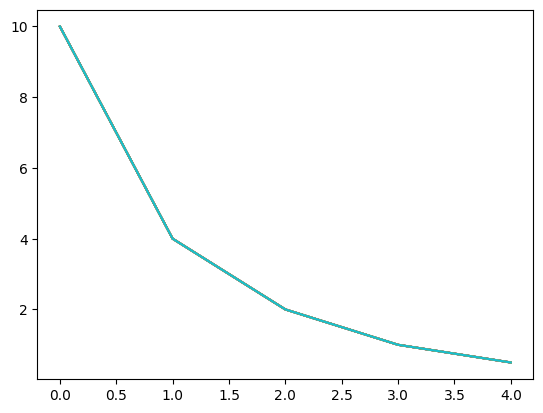

In [2]:
N_p = 10 # patients
N_t = 5 # time points (number of)
sc = 12 # scaling factor

y0 = np.zeros((N_p, N_t)) + np.array([10, 4, 2, 1, .5])

plt.plot(y0.T)
plt.show()

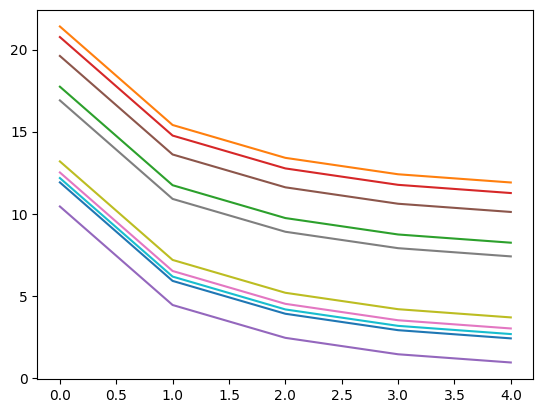

In [3]:
y_add = y0 + np.random.rand(N_p)[:, None] * sc

plt.plot(y_add.T)
plt.show()

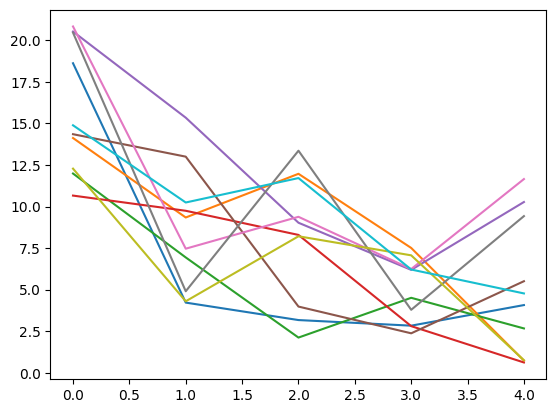

In [4]:
y_mult = y0 + np.random.rand(N_p, N_t) * sc

plt.plot(y_mult.T)
plt.show()

In [5]:
df_add = pd.DataFrame(data=y_add, columns=[f'T{i}' for i in range(N_t)])
df_add['Patient'] = np.arange(N_p) + 100
df_add = pd.melt(df_add, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_add, groups='Patient').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:              MixedLM   Dependent Variable:   y       
No. Observations:   50        Method:               REML    
No. Groups:         10        Scale:                0.0000  
Min. group size:    5         Log-Likelihood:       299.4735
Max. group size:    5         Converged:            Yes     
Mean group size:    5.0                                     
------------------------------------------------------------
            Coef.   Std.Err.      z      P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept   15.666     0.577      27.141 0.000 14.535 16.797
Week[T.T1]  -6.000     0.000 -540567.043 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -720756.057 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -810850.565 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -855897.818 0.000 -9.500 -9.500
Patient Var  3.332 31640.060                                
============================================================

"""

In [6]:
model.fe_params.to_numpy().shape

(5,)

In [7]:
np.empty(5).shape

(5,)

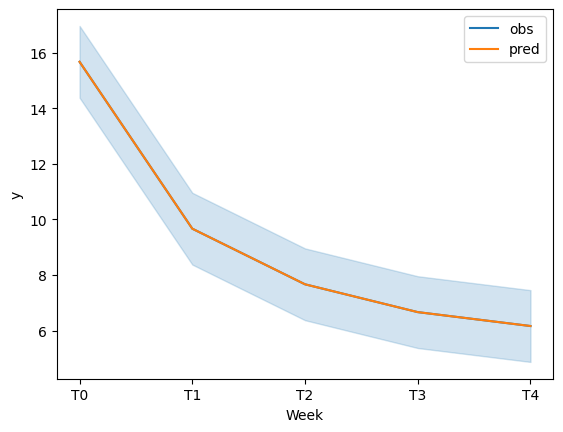

In [8]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_add, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [9]:
kill = np.random.randint(low=0, high=50, size=20)
df_add_kill = df_add.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_add_kill, groups='Patient').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:              MixedLM   Dependent Variable:   y       
No. Observations:   34        Method:               REML    
No. Groups:         10        Scale:                0.0000  
Min. group size:    1         Log-Likelihood:       147.8298
Max. group size:    5         Converged:            Yes     
Mean group size:    3.4                                     
------------------------------------------------------------
            Coef.   Std.Err.      z      P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept   15.666     0.719      21.788 0.000 14.257 17.075
Week[T.T1]  -6.000     0.000 -336992.352 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -418631.611 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -459497.716 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -453545.555 0.000 -9.500 -9.500
Patient Var  5.170 48074.182                                
============================================================

"""

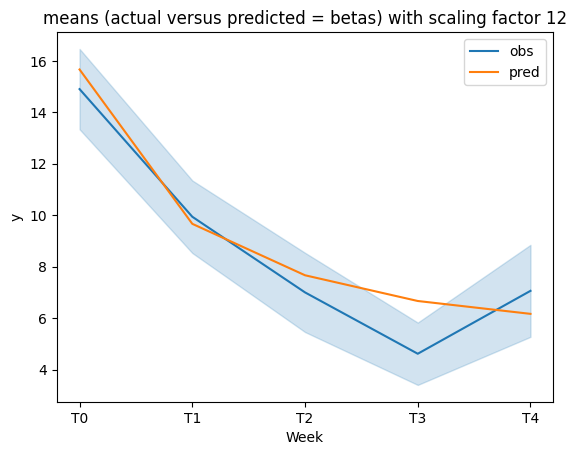

In [10]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()

# bi + b0 = mean(timepoint i) for i != 0
b[1:] += b[0] 
sem[1:] += sem[0]

sns.lineplot(data=df_add_kill, x='Week', y='y', errorbar='se', label = 'obs')
plt.plot(b,label = 'pred')

plt.legend()
plt.title(f"means (actual versus predicted = betas) with scaling factor {sc}")
plt.show()

## Multiplicative differences

In [11]:
df_mult = pd.DataFrame(data=y_mult, columns=[f'T{i}' for i in range(N_t)])
df_mult['Patient'] = np.arange(N_p) + 100
df_mult = pd.melt(df_mult, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

# log transform it
#df_mult['y'] = np.log(df_mult['y'])

model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient', re_formula = '~Week').fit()

model.summary()

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Mixed Linear Model Regression Results
=========================================================================
Model:                  MixedLM       Dependent Variable:       y        
No. Observations:       50            Method:                   REML     
No. Groups:             10            Scale:                    2.3960   
Min. group size:        5             Log-Likelihood:           -117.0832
Max. group size:        5             Converged:                Yes      
Mean group size:        5.0                                              
-------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
-------------------------------------------------------------------------
Intercept                    15.872    0.981  16.179 0.000  13.949 17.795
Week[T.T1]                   -7.322    1.397  -5.241 0.000 -10.060 -4.584
Week[T.T2]                   -7.750    1.300  -5.962 0.000 -10.298 -5.202
Week[T.T3]                  -10.920    1.172  -9.318 0.000 -13.217 -8.623
Week[T.T4]                  -10.824    0.845 -12.810 0.000 -12.481 -9.168
Patient Var                   7.229    2.893                             
Patient x Week[T.T1] Cov     -5.766    2.873                             
Week[T.T1] Var               14.722    6.421                             
Patient x Week[T.T2] Cov     -3.333    2.502                             
Week[T.T1] x Week[T.T2] Cov   3.076    3.320                             
Week[T.T2] Var               12.103    6.567                             
Patient x Week[T.T3] Cov     -7.161    3.078                             
Week[T.T1] x Week[T.T3] Cov   5.623    3.496                             
Week[T.T2] x Week[T.T3] Cov   5.727    3.817                             
Week[T.T3] Var                8.942    4.573                             
Patient x Week[T.T4] Cov      1.326    1.755                             
Week[T.T1] x Week[T.T4] Cov   1.039    3.097                             
Week[T.T2] x Week[T.T4] Cov  -1.643    4.089                             
Week[T.T3] x Week[T.T4] Cov  -0.184    1.959                             
Week[T.T4] Var                2.348    1.615                             
=========================================================================

"""

In [12]:
# catch warnings
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
store_exceptions = []
try:
    with warnings.catch_warnings():
        warnings.filterwarnings('error', category = ConvergenceWarning)
        model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient', re_formula = '~Week').fit()
    a, b = model.fe_params.to_numpy(), True
except Exception as e:
    store_exceptions.append(e)
    print('no')


no


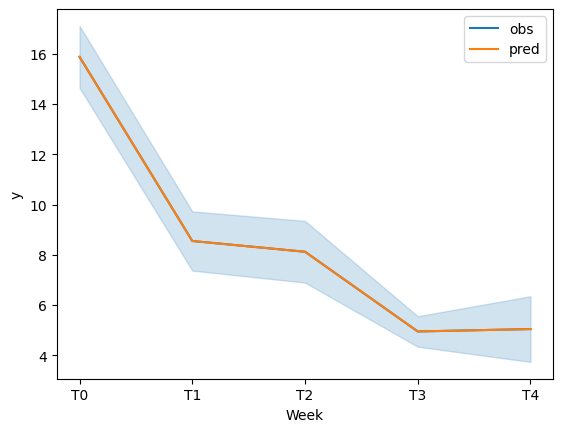

In [13]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [14]:
# same values killed as with the additive model
df_mult_kill = df_mult.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_mult_kill, groups='Patient', re_formula = '~Week').fit()

model.summary()


/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/UWO/mporwal2/Docume

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Mixed Linear Model Regression Results
========================================================================
Model:                  MixedLM       Dependent Variable:       y       
No. Observations:       34            Method:                   REML    
No. Groups:             10            Scale:                    3.1677  
Min. group size:        1             Log-Likelihood:           -78.2711
Max. group size:        5             Converged:                No      
Mean group size:        3.4                                             
------------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------------------
Intercept                    16.882    1.100 15.354 0.000  14.727 19.037
Week[T.T1]                   -7.860    1.557 -5.048 0.000 -10.912 -4.808
Week[T.T2]                   -8.522    1.540 -5.533 0.000 -11.540 -5.503
Week[T.T3]                  -11.936    2.145 -5.565 0.000 -16.139 -7.732
Week[T.T4]                  -10.368    1.465 -7.079 0.000 -13.239 -7.498
Patient Var                   5.944    3.008                            
Patient x Week[T.T1] Cov     -5.574    2.825                            
Week[T.T1] Var               13.703    6.141                            
Patient x Week[T.T2] Cov     -2.750    2.412                            
Week[T.T1] x Week[T.T2] Cov   2.695    3.076                            
Week[T.T2] Var                9.392    6.005                            
Patient x Week[T.T3] Cov     -5.286    5.328                            
Week[T.T1] x Week[T.T3] Cov   6.365    5.953                            
Week[T.T2] x Week[T.T3] Cov   3.184    3.776                            
Week[T.T3] Var                7.072    8.313                            
Patient x Week[T.T4] Cov      1.690    1.946                            
Week[T.T1] x Week[T.T4] Cov  -1.214    3.051                            
Week[T.T2] x Week[T.T4] Cov  -2.099    3.911                            
Week[T.T3] x Week[T.T4] Cov  -1.752                                     
Week[T.T4] Var                1.194                                     
========================================================================

"""

In [17]:
try:
        with warnings.catch_warnings():
            warnings.filterwarnings('error', category = ConvergenceWarning)
            model = smf.mixedlm('y~Week', data = df_mult, groups = 'subj').fit(maxiter = 400)
            print('converged', model.fe_params.to_numpy())
    
except Exception as e:
      print('not converged', model.fe_params.to_numpy())

not converged [ 16.88205773  -7.86016493  -8.52179624 -11.93553247 -10.36816878]


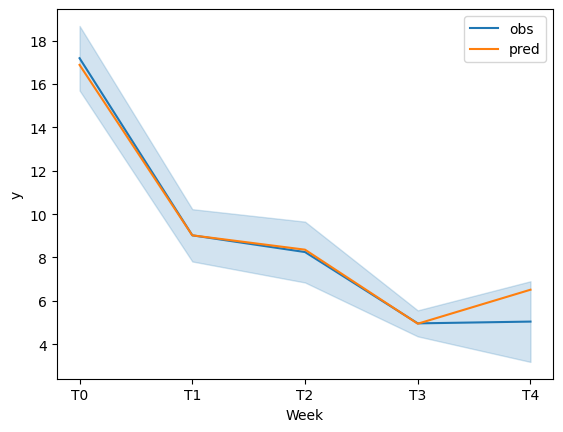

In [15]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult_kill, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)